### **Telco Customer Churn Predictor - Hypothesis Testing**

**Objective:** To develop a machine learning classification model that predicts customers who are likely to discontinue their telecom subscription services. The project aims to identify the key factors influencing customer churn through data cleaning, feature engineering, model training, and evaluation, enabling telecom companies to implement targeted customer retention strategies and reduce revenue loss.

**Guiding Principles for this Notebook:**  

+ Visualize relationship
+ Conduct hypothesis test
+ Record p-value
+ Calculate effect size
+ Rank features by effect size

**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import (chi2_contingency, mannwhitneyu)
from scipy.stats.contingency import association
from scipy.stats import probplot

**Load and Inspect Data**

In [2]:
data = pd.read_csv(r"C:\Users\KOLADE\OneDrive\Documents\AkoladeDSJourney\Telco-Customer-Churn-Prediction\data\processed\telco_customer_churn_feature_engineered.csv")
df = data.copy()

print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (7043, 25)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,NumServices,IsLongTermContract,AvgMonthlySpend,SpendCategory
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Yes,Electronic check,29.85,29.85,0,0-3 Months (Onboarding),2,0,29.85,Low
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,Mailed check,56.95,1889.50,0,1-3 Years (Established),4,1,55.57,Medium
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,1,0-3 Months (Onboarding),4,0,54.08,Medium
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,Bank transfer (automatic),42.30,1840.75,0,3+ Months (Loyal),4,1,40.91,Medium
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,1,0-3 Months (Onboarding),2,0,75.82,High


In [3]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'NumServices',
       'IsLongTermContract', 'AvgMonthlySpend', 'SpendCategory'],
      dtype='object')


In [4]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'NumServices']

df[num_features].head()

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,NumServices
0,1,29.85,29.85,29.85,2
1,34,56.95,1889.50,55.57,4
2,2,53.85,108.15,54.08,4
3,45,42.30,1840.75,40.91,4
4,2,70.70,151.65,75.82,2


In [5]:
df[num_features].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.85,118.75
TotalCharges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.80
AvgMonthlySpend,7043.0,64.698184,30.270690,0.00,35.650,70.300,90.17,121.40
NumServices,7043.0,4.146244,2.312720,1.00,2.000,4.000,6.00,9.00


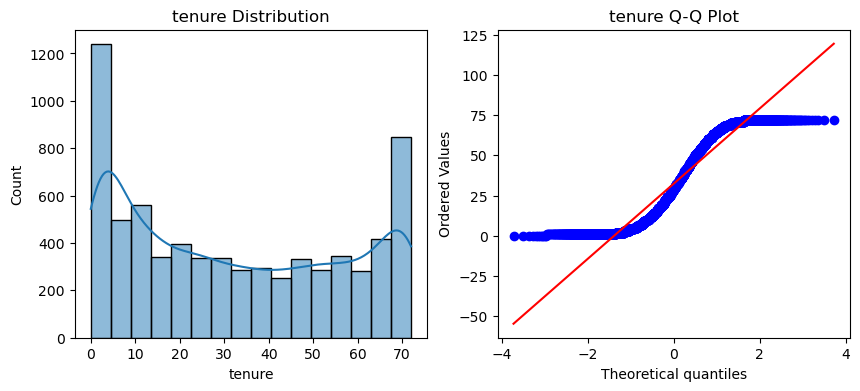

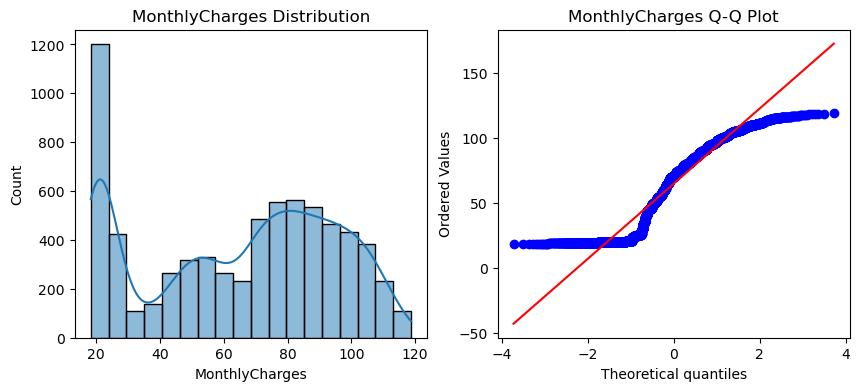

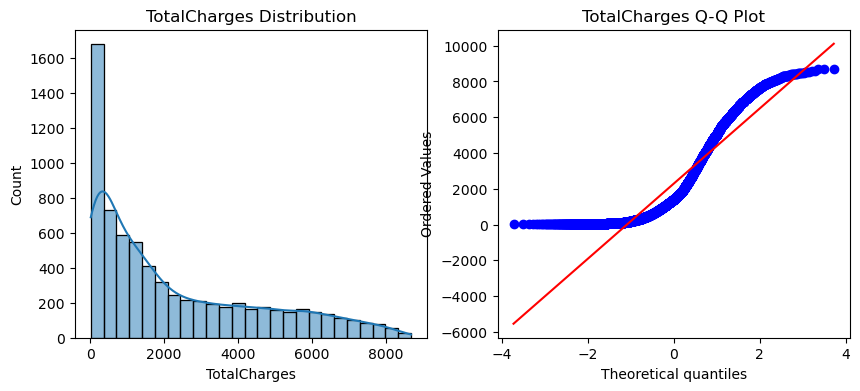

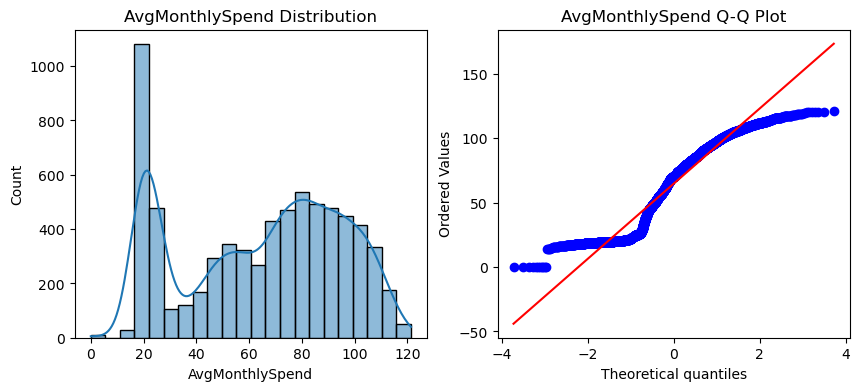

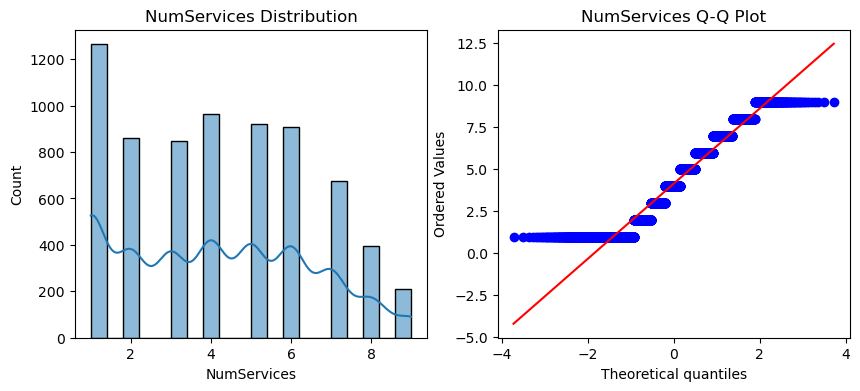

In [6]:
for col in num_features:
    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f'{col} Distribution')

    probplot(df[col], dist='norm', plot=ax[1])
    ax[1].set_title(f'{col} Q-Q Plot')

    plt.show()

In [7]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'NumServices',
       'IsLongTermContract', 'AvgMonthlySpend', 'SpendCategory'],
      dtype='object')

In [8]:
 cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'TenureGroup', 'IsLongTermContract', 'SpendCategory']

print(f"Number of Unique values in each columns: \n{df[cat_features].nunique()}")

Number of Unique values in each columns: 
gender                2
SeniorCitizen         2
Partner               2
Dependents            2
PhoneService          2
MultipleLines         3
InternetService       3
OnlineSecurity        3
OnlineBackup          3
DeviceProtection      3
TechSupport           3
StreamingTV           3
StreamingMovies       3
Contract              3
PaperlessBilling      2
PaymentMethod         4
TenureGroup           4
IsLongTermContract    2
SpendCategory         4
dtype: int64


In [9]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df['IsLongTermContract'] = df['IsLongTermContract'].map({0: 'No', 1: 'Yes'})

df[cat_features].head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TenureGroup,IsLongTermContract,SpendCategory
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,0-3 Months (Onboarding),No,Low
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1-3 Years (Established),Yes,Medium
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,0-3 Months (Onboarding),No,Medium
3,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),3+ Months (Loyal),Yes,Medium
4,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0-3 Months (Onboarding),No,High


In [10]:
df[num_features].head()

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,NumServices
0,1,29.85,29.85,29.85,2
1,34,56.95,1889.50,55.57,4
2,2,53.85,108.15,54.08,4
3,45,42.30,1840.75,40.91,4
4,2,70.70,151.65,75.82,2


#### **Hypothesis Testing Approach**

The Q-Q plots revealed substantial deviations from the theoretical normal reference line, indicating that the numerical features do not follow a normal distribution. In particular, variables such as `MonthlyCharges` exhibited multimodal patterns, while `tenure` and `TotalCharges` showed noticeable skewness. Given these distributional characteristics, parametric assumptions of normality are not strictly satisfied.

Therefore, the **Mann-Whitney U test** will be used as the primary hypothesis test for numerical features because:

* It is a non-parametric method and does not assume normality.
* It is robust to skewed and multimodal distributions.
* It is appropriate for comparing the distributions of churned and non-churned customer groups.

For categorical variables, the **Chi-Square Test of Independence** will be employed to determine whether there is a statistically significant association between each categorical feature and customer churn.

The hypotheses for the tests are defined as follows:

**Chi-Square Test (Categorical Features)**

* **Null Hypothesis $(H_{0})$:** The categorical feature is independent of customer churn.
* **Alternative Hypothesis $(H_{1})$:** The categorical feature is associated with customer churn.

**Mann-Whitney U Test (Numerical Features)**

* **Null Hypothesis $(H_{0})$:** The distribution of the numerical feature is the same for churned and non-churned customers.
* **Alternative Hypothesis $(H_{1})$:** The distribution of the numerical feature differs between churned and non-churned customers.

A significance level of **$\alpha$ = 0.05** will be used to determine statistical significance. Features with p-values below this threshold will be considered to have a significant relationship with customer churn and will receive additional attention during model development and business interpretation.


**For the Churn Project**

|Variable |Statistical Test |Effect Size |
|---------|-----------------|------------|
|Categorical Features |Chi-Square |Cramer's V|
|Numerical Features |Mann-Whitney U |Rank-Biserial Correlation|
|Final Predictive Model |logistic Regression |Odds Ratio|
|Model Evaluation |Classification Metrics |AUC, Precision, Recall, F1|

In [11]:
TARGET = 'Churn'

In [12]:
# functions for Effect Size Calculation

def cramers_v(contingency_table):
    """
    Computes Cramer's V effect size.
    """
    return association(contingency_table, method="cramer")


def rank_biserial(x, y):
    """
    Computes Rank-Biserial Correlation
    from Mann-Whitney U statistic.
    """
    u_stat, _ = mannwhitneyu(x, y, alternative='two-sided')

    n1 = len(x)
    n2 = len(y)

    rbc = (2 * u_stat) / (n1 * n2) - 1

    return abs(rbc)

In [13]:
# Categorical Hypothesis Testing
cat_results = []

for col in cat_features:

    contingency = pd.crosstab(df[col], df[TARGET])

    chi2, p_value, _, _ = chi2_contingency(contingency)

    effect_size = cramers_v(contingency)

    keep = (
        (p_value < 0.05)
        and
        (effect_size >= 0.10)
    )

    cat_results.append({
        "Feature": col,
        "Test": "Chi-Square",
        "P_Value": round(p_value, 6),
        "Effect_Size": round(effect_size, 3),
        "Keep": "Yes" if keep else "No"
    })

print(f"Categorical Hypothesis Testing Results: \n{pd.DataFrame(cat_results)}")

Categorical Hypothesis Testing Results: 
               Feature        Test   P_Value  Effect_Size Keep
0               gender  Chi-Square  0.486579        0.009   No
1        SeniorCitizen  Chi-Square  0.000000        0.151  Yes
2              Partner  Chi-Square  0.000000        0.150  Yes
3           Dependents  Chi-Square  0.000000        0.164  Yes
4         PhoneService  Chi-Square  0.338783        0.012   No
5        MultipleLines  Chi-Square  0.003464        0.040   No
6      InternetService  Chi-Square  0.000000        0.322  Yes
7       OnlineSecurity  Chi-Square  0.000000        0.347  Yes
8         OnlineBackup  Chi-Square  0.000000        0.292  Yes
9     DeviceProtection  Chi-Square  0.000000        0.282  Yes
10         TechSupport  Chi-Square  0.000000        0.343  Yes
11         StreamingTV  Chi-Square  0.000000        0.231  Yes
12     StreamingMovies  Chi-Square  0.000000        0.231  Yes
13            Contract  Chi-Square  0.000000        0.410  Yes
14    Paperles

In [14]:
# Numerical Hypothesis Testing
num_results = []

for col in num_features:

    churned = df[df[TARGET] == 1][col]
    retained = df[df[TARGET] == 0][col]

    stat, p_value = mannwhitneyu(
        churned,
        retained,
        alternative='two-sided'
    )

    effect_size = rank_biserial(churned, retained)

    keep = (
        (p_value < 0.05)
        and
        (effect_size >= 0.10)
    )

    num_results.append({
        "Feature": col,
        "Test": "Mann-Whitney U",
        "P_Value": round(p_value, 6),
        "Effect_Size": round(effect_size, 3),
        "Keep": "Yes" if keep else "No"
    })

print(f"Numerical Hypothesis Testing Results: \n{pd.DataFrame(num_results)}")

Numerical Hypothesis Testing Results: 
           Feature            Test   P_Value  Effect_Size Keep
0           tenure  Mann-Whitney U  0.000000        0.480  Yes
1   MonthlyCharges  Mann-Whitney U  0.000000        0.242  Yes
2     TotalCharges  Mann-Whitney U  0.000000        0.303  Yes
3  AvgMonthlySpend  Mann-Whitney U  0.000000        0.243  Yes
4      NumServices  Mann-Whitney U  0.683557        0.006   No


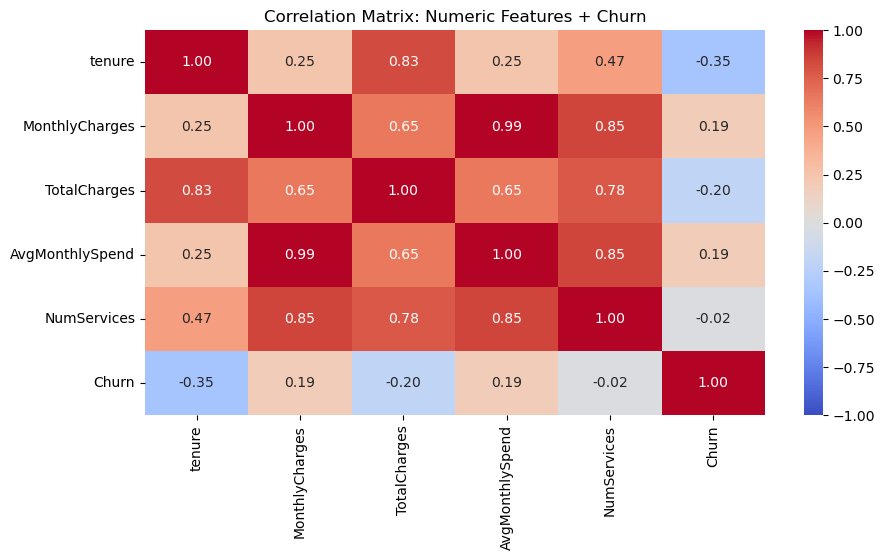

In [15]:
num_churn_features = num_features + ['Churn']
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_churn_features].corr(),
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt='.2f'
)
plt.title('Correlation Matrix: Numeric Features + Churn')
plt.show()

In [16]:
# Summary of Hypothesis Testing Results
hypothesis_summary = pd.DataFrame(
    cat_results + num_results
)

hypothesis_summary = hypothesis_summary.sort_values(
    by=["Keep", "Effect_Size"],
    ascending=[False, False]
)

hypothesis_summary.reset_index(
    drop=True,
    inplace=True
)

hypothesis_summary

,Feature,Test,P_Value,Effect_Size,Keep
0,tenure,Mann-Whitney U,0.000000,0.480,Yes
1,Contract,Chi-Square,0.000000,0.410,Yes
2,IsLongTermContract,Chi-Square,0.000000,0.405,Yes
3,TenureGroup,Chi-Square,0.000000,0.358,Yes
4,OnlineSecurity,Chi-Square,0.000000,0.347,Yes
5,TechSupport,Chi-Square,0.000000,0.343,Yes
6,InternetService,Chi-Square,0.000000,0.322,Yes
7,PaymentMethod,Chi-Square,0.000000,0.303,Yes
8,TotalCharges,Mann-Whitney U,0.000000,0.303,Yes
9,OnlineBackup,Chi-Square,0.000000,0.292,Yes


#### Hypothesis Testing and Multicollinearity Summary

Hypothesis testing was conducted to evaluate the statistical relationship between each feature and customer churn. The **Chi-Square Test of Independence** was applied to categorical variables, while the **Mann-Whitney U Test** was used for numerical variables due to the non-normal and, in some cases, multimodal nature of their distributions. Feature selection considered both **statistical significance (p-value < 0.05)** and **practical significance (effect size ≥ 0.10)**.

The results identified *`Contract`, `IsLongTermContract`, `TenureGroup`, `OnlineSecurity`, `TechSupport`, `InternetService`, `PaymentMethod`, and `tenure`* as the strongest predictors of churn. Conversely, *`gender`, `PhoneService`, `MultipleLines`, and `NumServices`* exhibited negligible effect sizes and were excluded from the modeling dataset.

A correlation analysis was subsequently performed to assess multicollinearity among numerical and engineered features. Strong correlations were observed between *`MonthlyCharges` and `AvgMonthlySpend` (r = 0.99)*, *`tenure` and `TenureGroup`*, and *`Contract` and `IsLongTermContract`*, indicating substantial redundancy. To preserve information while reducing multicollinearity, the original variables were retained and their engineered counterparts removed.

**Features Retained for Modeling**

* Numerical Features: *`tenure`, `MonthlyCharges`, `TotalCharges`*

* Categorical Features: *`SeniorCitizen`, `Partners`, `Dependents`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `SpendCategory`*

**Features Removed from Modeling**

| Feature            | Reason                                               |
| ------------------ | ---------------------------------------------------- |
| gender             | Negligible effect size (Cramér's V = 0.009)          |
| PhoneService       | Negligible effect size (Cramér's V = 0.012)          |
| MultipleLines      | Weak practical significance (Cramér's V = 0.040)     |
| NumServices        | No significant relationship with churn (RBC = 0.006) |
| AvgMonthlySpend    | Highly correlated with MonthlyCharges (r = 0.99)     |
| IsLongTermContract | Redundant with Contract                              |
| TenureGroup        | Redundant with tenure                                |

These selections ensure that the final modeling dataset contains statistically meaningful, practically relevant, and minimally redundant predictors, thereby improving model interpretability and reducing the risk of multicollinearity-related issues.


In [17]:
col_to_keep = hypothesis_summary[hypothesis_summary['Keep'] == 'Yes']['Feature'].tolist()

col_to_keep = [col for col in col_to_keep if col not in ['AvgMonthlySpend', 'IsLongTermContract', 'TenureGroup']]

predictors = df[col_to_keep + [TARGET]]

print(f"Predictors Shape: {predictors.shape}")
print(f"Original Data Shape: {df.shape}")

Predictors Shape: (7043, 18)
Original Data Shape: (7043, 25)


In [18]:
predictors.head()

,tenure,Contract,OnlineSecurity,TechSupport,InternetService,PaymentMethod,TotalCharges,OnlineBackup,DeviceProtection,MonthlyCharges,StreamingTV,StreamingMovies,SpendCategory,PaperlessBilling,Dependents,SeniorCitizen,Partner,Churn
0,1,Month-to-month,No,No,DSL,Electronic check,29.85,Yes,No,29.85,No,No,Low,Yes,No,No,Yes,0
1,34,One year,Yes,No,DSL,Mailed check,1889.50,No,Yes,56.95,No,No,Medium,No,No,No,No,0
2,2,Month-to-month,Yes,No,DSL,Mailed check,108.15,Yes,No,53.85,No,No,Medium,Yes,No,No,No,1
3,45,One year,Yes,Yes,DSL,Bank transfer (automatic),1840.75,No,Yes,42.30,No,No,Medium,No,No,No,No,0
4,2,Month-to-month,No,No,Fiber optic,Electronic check,151.65,No,No,70.70,No,No,High,Yes,No,No,No,1


In [19]:
predictors.to_csv(r"C:\Users\KOLADE\OneDrive\Documents\AkoladeDSJourney\Telco-Customer-Churn-Prediction\data\processed\telco_customer_churn_predictors.csv", index=False)
print("Predictors saved to CSV successfully.")

Predictors saved to CSV successfully.
